# Building Causal Arguments with DoWhy

In [40]:
# pip install dowhy==0.11.1 pandas numpy statsmodels networkx matplotlib

In [10]:
import numpy as np
import pandas as pd
from dowhy import CausalModel
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
n = 1000
ses = np.random.normal(0, 1, n)
edu = 0.6 * ses + np.random.normal(0, 1, n)
income = 1.2 * edu + 0.8 * ses + np.random.normal(0, 1, n)
df = pd.DataFrame({"Education": edu, "SES": ses, "Income": income})
df.head()

,Education,SES,Income
0,1.697384,0.496714,1.759054
1,0.841675,-0.138264,0.754880
2,0.448243,0.647689,0.263623
3,0.266881,1.523030,1.230720
4,0.557731,-0.234153,-1.411660


## DAG

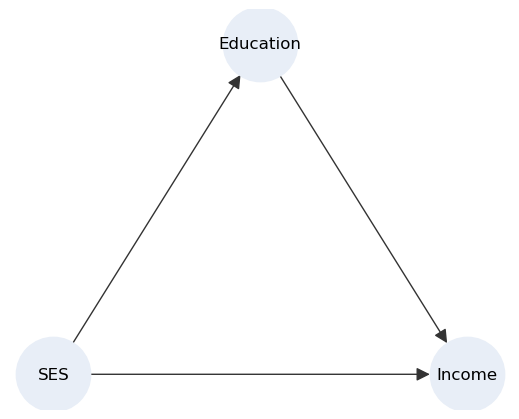

In [11]:
G = nx.DiGraph()
G.add_edges_from([
    ("SES", "Education"),
    ("Education", "Income"),
    ("SES", "Income"), 
])
pos = {
    "SES": (0.0, 0.0),
    "Education": (1.0, 1.732),  # ~sqrt(3) to look equilateral
    "Income": (2.0, 0.0),
}
plt.figure(figsize=(5, 4))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=2800,
    node_color="#E8EEF7",
    edge_color="#333333",
    arrows=True,
    arrowstyle="-|>",
    arrowsize=20,
    linewidths=1.6,
    font_size=12,
)
plt.axis("off")
plt.tight_layout()
plt.show()

## Model

In [12]:
# Define treatment and outcome
treatment = "Education"
outcome = "Income"

# Create causal model (use backdoor with SES as a confounder)
model = CausalModel(
    data=df,
    treatment=treatment,
    outcome=outcome,
    common_causes=["SES"] )

## Identify

In [13]:
# Identify effect
identified_estimand = model.identify_effect()
print("\nIdentified estimand:\n", identified_estimand)


Identified estimand:
 Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                     
────────────(E[Income|SES])
d[Education]               
Estimand assumption 1, Unconfoundedness: If U→{Education} and U→Income then P(Income|Education,SES,U) = P(Income|Education,SES)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                     
────────────(E[Income|SES])
d[Education]               
Estimand assumption 1, Unconfoundedness: If U→{Education} and U→Income then P(Income|Education,SES,U) = P(Income|Education,SES)



## Estimate

In [14]:
# Estimate ATE via backdoor linear regression
ate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    confidence_intervals=True
)
print("\n[OLS] Estimated ATE (Education to Income):", ate.value)
print("95% CI (OLS):", ate.get_confidence_intervals())


[OLS] Estimated ATE (Education to Income): 1.1898226578753033
95% CI (OLS): [[1.12851504 1.25113027]]


## Refute

In [15]:
# Placebo Treatment Refuter
ref_placebo = model.refute_estimate(
    identified_estimand, ate, method_name="placebo_treatment_refuter"
)
print("\nRefute: Placebo treatment\n", ref_placebo)

# Random/Common Cause Refuter
ref_random_cc = model.refute_estimate(
    identified_estimand, ate, method_name="random_common_cause"
)
print("\nRefute: Random common cause\n", ref_random_cc)

# Bootstrap Refuter
ref_boot = model.refute_estimate(
    identified_estimand, ate, method_name="bootstrap_refuter", num_simulations=200
)
print("\nRefute: Bootstrap\n", ref_boot)

# Data Subset Refuter
ref_subset_ols = model.refute_estimate(
    identified_estimand,
    ate,
    method_name="data_subset_refuter",
    subset_fraction=0.8,      # use 80% of data in each simulation
    num_simulations=100,      # how many random subsets to try
    random_state=42           # for reproducibility
)
print("\nRefute: Data Subset (OLS)\n", ref_subset_ols)

# Sensitivity to unobserved confounding
ref_unobs = model.refute_estimate(
    identified_estimand, ate,
    method_name="add_unobserved_common_cause",
    confounders_effect_on_treatment="linear",
    confounders_effect_on_outcome="linear",
    effect_strength_on_treatment=0.2,
    effect_strength_on_outcome=0.2
)
print("\nRefute: Add unobserved common cause\n", ref_unobs)


Refute: Placebo treatment
 Refute: Use a Placebo Treatment
Estimated effect:1.1898226578753033
New effect:0.0
p value:1.0


Refute: Random common cause
 Refute: Add a random common cause
Estimated effect:1.1898226578753033
New effect:1.1898309483819505
p value:0.96


Refute: Bootstrap
 Refute: Bootstrap Sample Dataset
Estimated effect:1.1898226578753033
New effect:1.1928780547228655
p value:0.9299999999999999


Refute: Data Subset (OLS)
 Refute: Use a subset of data
Estimated effect:1.1898226578753033
New effect:1.1826491821847254
p value:0.0


Refute: Add unobserved common cause
 Refute: Add an Unobserved Common Cause
Estimated effect:1.1898226578753033
New effect:1.1141837406732364

